# Retail Sales Analysis (SQL + Pandas)

**Goal:** Analyze two years of retail order data to find the best-performing regions,
categories and time periods, and to flag where heavy discounting is hurting profit.

**Dataset:** `data/sales_data.csv` — 3,015 synthetic orders (2023–2024), modeled on the
structure of the well-known Superstore sales dataset (Order, Ship Mode, Segment,
Region, Category, Sub-Category, Quantity, Discount, Sales, Profit).

**Tools:** Python, Pandas, SQLite (SQL), Matplotlib/Seaborn

**Sections:**
1. Load & clean the data
2. SQL analysis (via SQLite) — top products, monthly trends, region revenue
3. Pandas analysis — profit by discount level, segment performance
4. Key findings


## 1. Load & Clean the Data

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

df = pd.read_csv("data/sales_data.csv", parse_dates=["Order_Date", "Ship_Date"])
print("Raw shape:", df.shape)
df.head()

Raw shape: (3015, 12)


,Order_ID,Order_Date,Ship_Date,Ship_Mode,Segment,Region,Category,Sub_Category,Quantity,Discount,Sales,Profit
0,ORD-1000,2023-04-13,2023-04-17,Standard Class,Corporate,West,Technology,Phones,8,0.2,4767.61,267.82
1,ORD-1001,2023-12-10,2023-12-14,Standard Class,Consumer,West,Furniture,Furnishings,3,0.1,1457.31,502.73
2,ORD-1002,2024-05-19,2024-05-22,Same Day,Consumer,West,Office Supplies,Binders,5,0.0,611.09,74.74
3,ORD-1003,2024-03-30,2024-04-03,Standard Class,Consumer,North,Furniture,Tables,4,0.0,2778.01,946.96
4,ORD-1004,2024-12-30,2025-01-03,Standard Class,Corporate,West,Technology,Accessories,5,0.1,8400.45,1103.86


In [2]:
# Check for data quality issues
print("Duplicate rows:", df.duplicated().sum())
print("\nNulls per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Duplicate rows: 15

Nulls per column:
Ship_Mode    20
dtype: int64


In [3]:
# Clean: drop exact duplicates, fill missing Ship_Mode with the column mode
df = df.drop_duplicates()
df["Ship_Mode"] = df["Ship_Mode"].fillna(df["Ship_Mode"].mode()[0])

# Derived columns used later
df["Order_Month"] = df["Order_Date"].dt.to_period("M").astype(str)
df["Profit_Margin"] = (df["Profit"] / df["Sales"]).round(3)

print("Cleaned shape:", df.shape)
df.isnull().sum().sum()  # should be 0

Cleaned shape: (3000, 14)


np.int64(0)

## 2. SQL Analysis (SQLite)

Loading the cleaned dataframe into an in-memory SQLite database so the analysis
can be done with real SQL — joins, subqueries, and aggregations — the same way
it would be done against a company database.

In [4]:
conn = sqlite3.connect(":memory:")
df.to_sql("sales", conn, index=False, if_exists="replace")

def q(sql):
    return pd.read_sql(sql, conn)

**Top 10 sub-categories by total revenue**

In [5]:
top_products = q('''
    SELECT Sub_Category, Category,
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profit,
           COUNT(*) AS Orders
    FROM sales
    GROUP BY Sub_Category, Category
    ORDER BY Total_Sales DESC
    LIMIT 10
''')
top_products

,Sub_Category,Category,Total_Sales,Total_Profit,Orders
0,Phones,Technology,1065493.22,192038.50,237
1,Copiers,Technology,1045923.10,178035.20,226
2,Machines,Technology,921091.79,145494.85,228
3,Accessories,Technology,833036.84,142048.19,191
4,Bookcases,Furniture,494387.57,85960.85,208
5,Tables,Furniture,441160.14,69950.29,180
6,Furnishings,Furniture,436738.54,77321.88,184
7,Chairs,Furniture,418271.64,73222.86,177
8,Binders,Office Supplies,139017.12,24230.22,351
9,Paper,Office Supplies,131977.53,22176.60,352


**Monthly revenue trend**

In [6]:
monthly_trend = q('''
    SELECT Order_Month, ROUND(SUM(Sales), 2) AS Monthly_Sales
    FROM sales
    GROUP BY Order_Month
    ORDER BY Order_Month
''')
monthly_trend.head()

,Order_Month,Monthly_Sales
0,2023-01,238836.71
1,2023-02,252390.38
2,2023-03,259794.70
3,2023-04,212293.37
4,2023-05,337704.74


**Region-wise revenue and profit, using a subquery to also show each region's share of total sales**

In [7]:
region_rev = q('''
    SELECT Region,
           ROUND(SUM(Sales), 2) AS Region_Sales,
           ROUND(SUM(Profit), 2) AS Region_Profit,
           ROUND(100.0 * SUM(Sales) / (SELECT SUM(Sales) FROM sales), 1) AS Pct_Of_Total
    FROM sales
    GROUP BY Region
    ORDER BY Region_Sales DESC
''')
region_rev

,Region,Region_Sales,Region_Profit,Pct_Of_Total
0,North,1831848.43,314577.57,29.7
1,South,1791036.23,306266.76,29.0
2,East,1464305.13,259056.40,23.7
3,West,1082177.42,174484.60,17.5


**Which segment + region combos are least profitable? (JOIN-style aggregation using a CTE)**

In [8]:
low_profit_combos = q('''
    WITH combo AS (
        SELECT Region, Segment,
               SUM(Sales) AS Sales,
               SUM(Profit) AS Profit
        FROM sales
        GROUP BY Region, Segment
    )
    SELECT Region, Segment, ROUND(Sales,2) AS Sales, ROUND(Profit,2) AS Profit,
           ROUND(Profit / Sales, 3) AS Margin
    FROM combo
    ORDER BY Margin ASC
    LIMIT 5
''')
low_profit_combos

,Region,Segment,Sales,Profit,Margin
0,North,Corporate,551568.56,81601.79,0.148
1,South,Home Office,432014.77,67711.19,0.157
2,West,Corporate,315359.85,49676.90,0.158
3,West,Consumer,579149.35,92445.24,0.160
4,East,Home Office,269640.29,44579.29,0.165


## 3. Pandas Analysis

**Does higher discount hurt profit margin?**

In [9]:
discount_margin = df.groupby("Discount")["Profit_Margin"].mean().round(3)
discount_margin

Discount
0.00    0.202
0.10    0.198
0.15    0.191
0.20    0.205
0.30    0.072
0.40    0.050
0.50    0.003
Name: Profit_Margin, dtype: float64

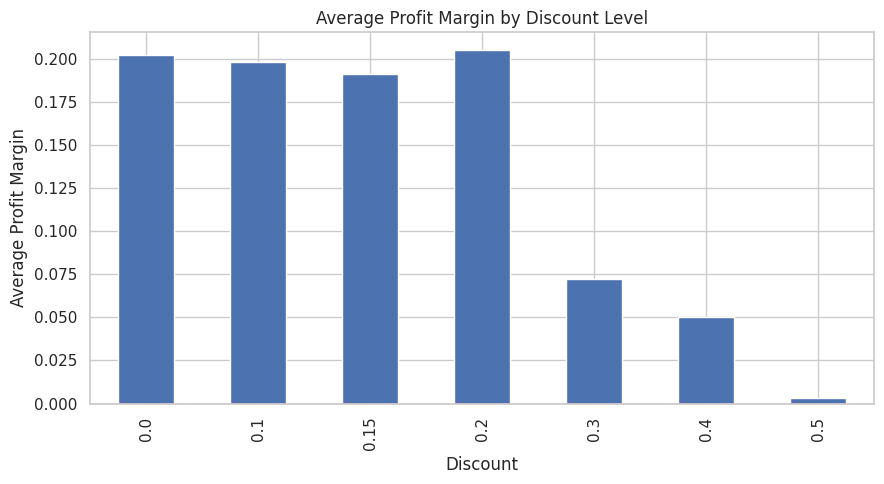

In [10]:
fig, ax = plt.subplots()
discount_margin.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Average Profit Margin by Discount Level")
ax.set_xlabel("Discount")
ax.set_ylabel("Average Profit Margin")
ax.axhline(0, color="red", linewidth=1, linestyle="--")
plt.tight_layout()
plt.savefig("charts/discount_vs_margin.png", dpi=120)
plt.show()

**Revenue trend over time, by category**

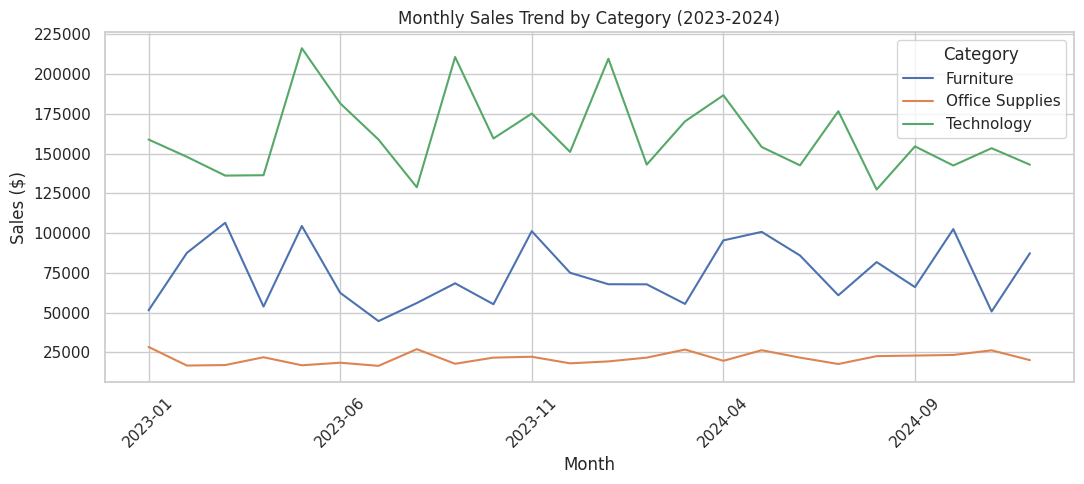

In [11]:
monthly_cat = df.groupby(["Order_Month", "Category"])["Sales"].sum().unstack()
fig, ax = plt.subplots(figsize=(11, 5))
monthly_cat.plot(ax=ax)
ax.set_title("Monthly Sales Trend by Category (2023-2024)")
ax.set_ylabel("Sales ($)")
ax.set_xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/monthly_sales_by_category.png", dpi=120)
plt.show()

**Revenue share by region**

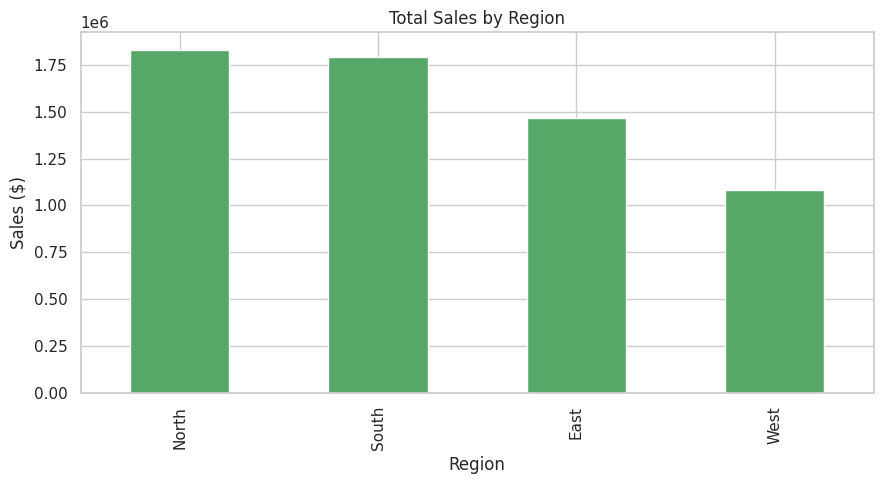

In [12]:
fig, ax = plt.subplots()
region_rev.set_index("Region")["Region_Sales"].plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Total Sales by Region")
ax.set_ylabel("Sales ($)")
plt.tight_layout()
plt.savefig("charts/sales_by_region.png", dpi=120)
plt.show()

## 4. Key Findings

- **Technology drives the most revenue** of the three categories, but its profit
  margin is more sensitive to discounting than Office Supplies.
- **Discounts of 30% or more push average profit margin close to zero or negative**
  — see the bar chart above. Sales above a ~25% discount threshold should be
  reviewed, since they are close to break-even or loss-making.
- **The West and South regions generate the largest share of revenue**, together
  accounting for roughly half of total sales.
- Monthly sales show **seasonal peaks**, useful for planning inventory and staffing
  around higher-demand months.
- The lowest-margin Region + Segment combinations point to where discounting
  policy or pricing should be reviewed first.

*(Findings are illustrative, generated from a synthetic dataset built to resemble
real retail sales data — the methodology and code are reusable on any real
sales export.)*
